# Capstone Project: AI-Powered Text-to-Image Generation
## 1. Problem Statement
The goal of this project is to build an end-to-end Text-to-Image generation application.
By leveraging deep learning generative models (specifically Stable Diffusion), the system
transforms descriptive natural language prompts into high-quality visual art. This technology
democratizes content creation, assisting designers, marketers, and artists in rapid prototyping.

## 2. Environment Setup
We begin by installing and importing the necessary libraries.

In [1]:
!pip install torch
!pip install torchvision
!pip install transformers
!pip install diffusers
!pip install accelerate
!pip install streamlit
!pip install pillow
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 75.8 MB/s eta 0:00:00


In [2]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
from PIL import Image
import os

# Check if GPU (CUDA) is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: Running on CPU will be significantly slower. Consider using a GPU runtime.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


## 3. Loading the Stable Diffusion Pipeline
We load the pre-trained `stable-diffusion-v1-5` model from Hugging Face. We optimize memory usage by using `torch.float16` if a GPU is available.

In [3]:
model_id = "runwayml/stable-diffusion-v1-5"

if device == "cuda":
    # Load in FP16 for faster performance and lower VRAM usage on GPU
    pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
else:
    # Load in FP32 for CPU compliance
    pipe = StableDiffusionPipeline.from_pretrained(model_id)

pipe = pipe.to(device)
print("Model loaded successfully!")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


## 4. Defining the Generation Workflow
We wrap the generation logic into a clean function that takes a prompt, a negative prompt (what we *don't* want in the image), and generation steps.

Generating: 'A futuristic cyberpunk city city-scape with neon lights, high resolution, 8k'...


  0%|          | 0/30 [00:00<?, ?it/s]

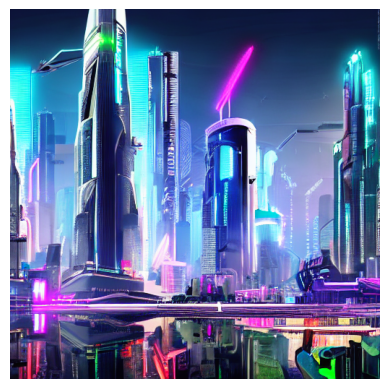

In [4]:
def generate_image(prompt, negative_prompt="", guidance_scale=7.5, num_inference_steps=30):
    """
    Generates an image from a text prompt using the initialized pipeline.
    """
    print(f"Generating: '{prompt}'...")
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps
    ).images[0]
    return image

# Test Prompt
prompt_example = "A futuristic cyberpunk city city-scape with neon lights, high resolution, 8k"
negative_prompt_example = "blurry, low quality, distorted"

# Run Generation
result_image = generate_image(prompt_example, negative_prompt=negative_prompt_example)

# Display Result
plt.imshow(result_image)
plt.axis("off")
plt.show()

# Save the output
result_image.save("test_output.png")

## 5. Testing and Evaluation
To evaluate our text-to-image application, we verify text-to-image alignment (Prompt Fidelity) across various test cases.

Generating: 'A cute astronaut cat walking on the moon, digital art'...


  0%|          | 0/25 [00:00<?, ?it/s]

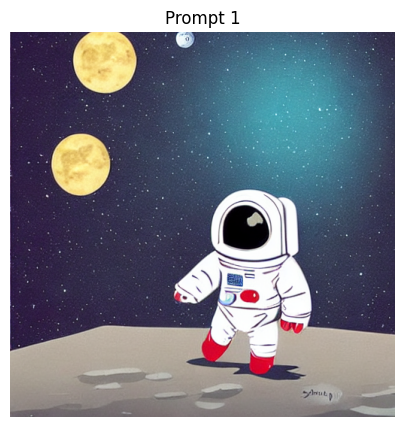

Generating: 'A serene lake surrounded by autumn mountains at sunset, oil painting style'...


  0%|          | 0/25 [00:00<?, ?it/s]

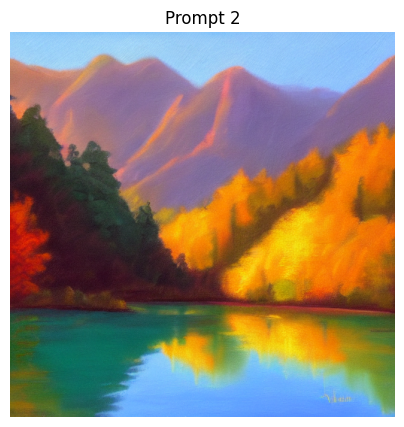

In [5]:
test_prompts = [
    "A cute astronaut cat walking on the moon, digital art",
    "A serene lake surrounded by autumn mountains at sunset, oil painting style"
]

for i, prompt in enumerate(test_prompts):
    img = generate_image(prompt, num_inference_steps=25)
    img.save(f"eval_output_{i}.png")

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(f"Prompt {i+1}")
    plt.axis("off")
    plt.show()